In [2]:
import os
import glob
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as ssim

# ==========================================
# 1. Hyperparameters & Configuration
# ==========================================
class Config:
    DATA_DIR = "/kaggle/input/datasets/greatgamedota/ffhq-face-data-set"
    IMG_SIZE = 128
    BATCH_SIZE = 32
    TIMESTEPS = 300
    EPOCHS = 30 # Adjust based on Kaggle time limits
    LR = 1e-4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    CHANNELS = 3

cfg = Config()
print(f"Using device: {cfg.DEVICE}")

Using device: cuda


In [3]:
# ==========================================
# 2. Dataset & DataLoader (Part 1)
# ==========================================
class FFHQDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        # Recursively find all images in the Kaggle dataset folder
        self.image_paths = glob.glob(os.path.join(root_dir, '**', '*.*'), recursive=True)
        self.image_paths = [p for p in self.image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

# DDPM requires images in [-1, 1] range
transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # [-1, 1]
])

dataset = FFHQDataset(cfg.DATA_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
print(f"Total images found: {len(dataset)}")

Total images found: 70000


In [4]:
# ==========================================
# 3. Forward Diffusion Process (Part 2)
# ==========================================
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(cfg.TIMESTEPS)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Move to device
alphas_cumprod = alphas_cumprod.to(cfg.DEVICE)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

def extract(a, t, x_shape):
    """Extract appropriate t index for a batch of images."""
    batch_size = t.shape[0]
    out = a.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

def q_sample(x_start, t, noise=None):
    """Forward process: q(x_t | x_0). Adds noise to the image."""
    if noise is None:
        noise = torch.randn_like(x_start)
    
    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape)
    
    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

In [5]:
# ==========================================
# 4. Reverse Process: U-Net Backbone (Part 3)
# ==========================================
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        h = self.bn1(self.relu(self.conv1(x)))
        time_emb = self.time_mlp(t)[:, :, None, None]
        h = h + time_emb
        h = self.bn2(self.relu(self.conv2(h)))
        return h

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        time_dim = 128
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )
        
        # Channel Progression: 64 -> 128 -> 256
        self.down1 = Block(cfg.CHANNELS, 64, time_dim)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = Block(64, 128, time_dim)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = Block(128, 256, time_dim)
        
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up_block1 = Block(256, 128, time_dim) # 256 because of skip connection
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up_block2 = Block(128, 64, time_dim)
        
        self.out = nn.Conv2d(64, cfg.CHANNELS, 1)

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        
        # Downsample
        x1 = self.down1(x, t)
        p1 = self.pool1(x1)
        x2 = self.down2(p1, t)
        p2 = self.pool2(x2)
        x3 = self.down3(p2, t)
        
        # Upsample
        u1 = self.up1(x3)
        u1 = torch.cat([u1, x2], dim=1) # Skip connection
        u1 = self.up_block1(u1, t)
        
        u2 = self.up2(u1)
        u2 = torch.cat([u2, x1], dim=1) # Skip connection
        u2 = self.up_block2(u2, t)
        
        return self.out(u2)

model = UNet().to(cfg.DEVICE)

Starting Training...


/tmp/ipykernel_57/1760983319.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # Mixed Precision
/tmp/ipykernel_57/1760983319.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/30 | Loss: 0.0870
Epoch 2/30 | Loss: 0.0523
Epoch 3/30 | Loss: 0.0473
Epoch 4/30 | Loss: 0.0447
Epoch 5/30 | Loss: 0.0427
Epoch 6/30 | Loss: 0.0416
Epoch 7/30 | Loss: 0.0405
Epoch 8/30 | Loss: 0.0404
Epoch 9/30 | Loss: 0.0395
Epoch 10/30 | Loss: 0.0397
Epoch 11/30 | Loss: 0.0390
Epoch 12/30 | Loss: 0.0384
Epoch 13/30 | Loss: 0.0378
Epoch 14/30 | Loss: 0.0377
Epoch 15/30 | Loss: 0.0372
Epoch 16/30 | Loss: 0.0375
Epoch 17/30 | Loss: 0.0373
Epoch 18/30 | Loss: 0.0373
Epoch 19/30 | Loss: 0.0371
Epoch 20/30 | Loss: 0.0369
Epoch 21/30 | Loss: 0.0366
Epoch 22/30 | Loss: 0.0366
Epoch 23/30 | Loss: 0.0361
Epoch 24/30 | Loss: 0.0361
Epoch 25/30 | Loss: 0.0364
Epoch 26/30 | Loss: 0.0359
Epoch 27/30 | Loss: 0.0363
Epoch 28/30 | Loss: 0.0364
Epoch 29/30 | Loss: 0.0357
Epoch 30/30 | Loss: 0.0355


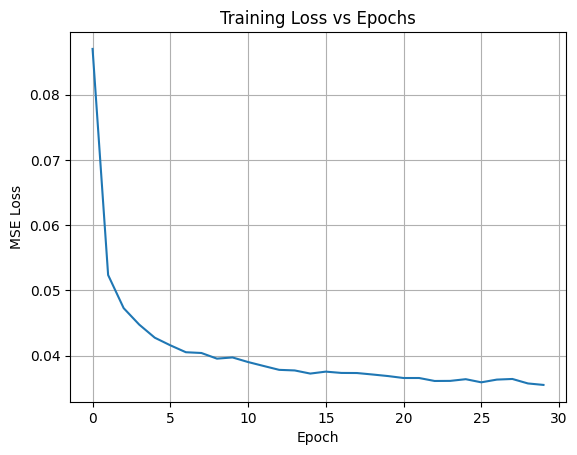

In [6]:
# ==========================================
# 5. Training Setup (Part 4)
# ==========================================
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR)
criterion = nn.MSELoss()
scaler = GradScaler() # Mixed Precision

loss_history = []

print("Starting Training...")
model.train()
for epoch in range(cfg.EPOCHS):
    epoch_loss = 0
    for batch in dataloader:
        batch = batch.to(cfg.DEVICE)
        
        # 1. Random timestep for each image in batch
        t = torch.randint(0, cfg.TIMESTEPS, (batch.shape[0],), device=cfg.DEVICE).long()
        
        # 2. Add noise
        noise = torch.randn_like(batch)
        x_noisy = q_sample(batch, t, noise)
        
        # 3. Predict noise using Mixed Precision
        optimizer.zero_grad()
        with autocast():
            predicted_noise = model(x_noisy, t)
            loss = criterion(predicted_noise, noise)
            
        # 4. Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{cfg.EPOCHS} | Loss: {avg_loss:.4f}")

# Plot Training Logs
plt.plot(loss_history)
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

In [7]:
# ==========================================
# 6. Sampling & Reverse Process
# ==========================================
@torch.no_grad()
def p_sample(model, x, t, t_index):
    """Single step of the reverse process."""
    betas_t = extract(betas.to(cfg.DEVICE), t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_alphas_t = extract(1.0 / torch.sqrt(alphas.to(cfg.DEVICE)), t, x.shape)
    
    # Equation 11 in the DDPM paper
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )
    
    if t_index == 0:
        return model_mean
    else:
        posterior_variance_t = extract(betas.to(cfg.DEVICE), t, x.shape) # Simplified variance
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

@torch.no_grad()
def p_sample_loop(model, shape, start_t=None, start_img=None, return_all=False):
    """Generates images from noise (or reconstructs from a specific timestep)."""
    device = cfg.DEVICE
    b = shape[0]
    
    if start_img is None:
        img = torch.randn(shape, device=device)
        start_t = cfg.TIMESTEPS - 1
    else:
        img = start_img
        
    imgs = []
    for i in reversed(range(0, start_t + 1)):
        t = torch.full((b,), i, device=device, dtype=torch.long)
        img = p_sample(model, img, t, i)
        
        if return_all and i % (cfg.TIMESTEPS // 10) == 0:
            imgs.append(img.cpu())
            
    if return_all:
        imgs.append(img.cpu())
        return imgs
    return img

def denormalize(tensor):
    """Converts [-1, 1] tensor back to [0, 1] for visualization."""
    return (tensor + 1.0) / 2.0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.013663352..1.0111566].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42577356..1.3708974].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9420941..1.9777377].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6849446..2.3720555].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9317551..2.4198446].


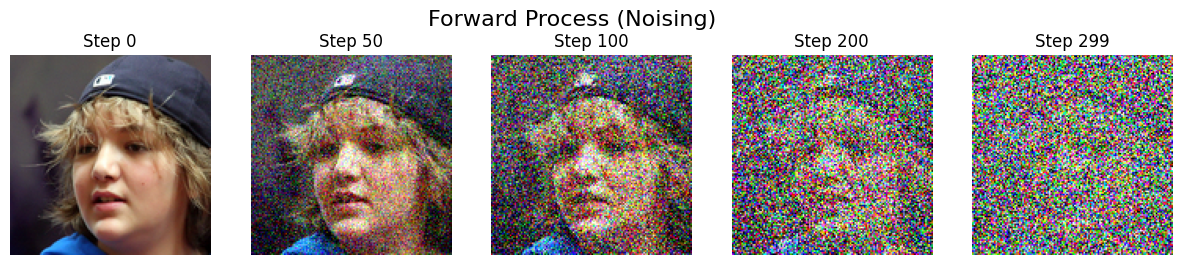

Generating new image from pure noise...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5905473..2.6128573].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5177639..2.3820724].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4125897..2.3433707].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.366382..2.218229].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.007209..2.13443].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9343133..2.0535748].


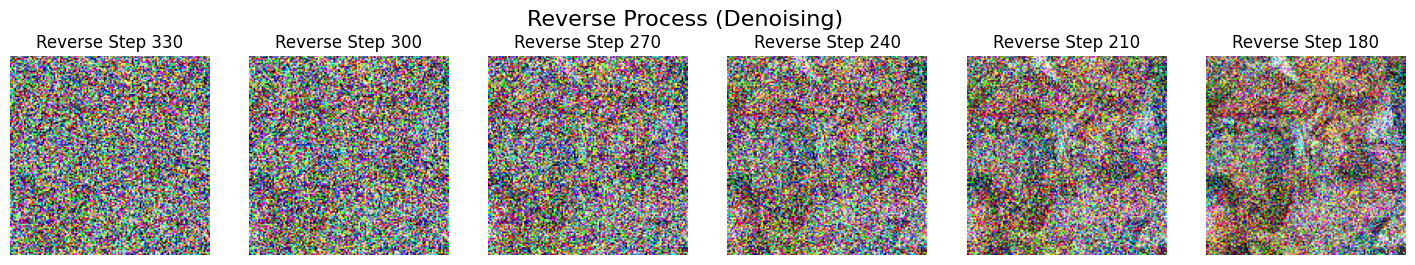

Generating 5 novel faces...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0060790777..0.99359035].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.014002621..1.0552491].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04068303..0.97488844].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03236419..0.9456627].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.037371635..1.1087922].


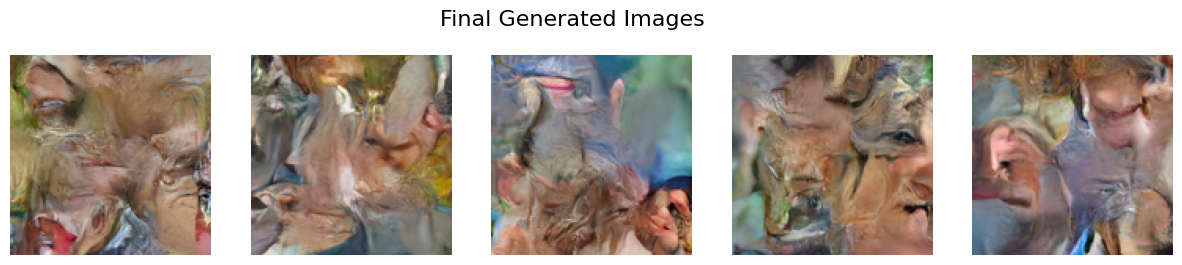

In [8]:
# ==========================================
# 7. Visualization Module & Generation (Part 6)
# ==========================================
model.eval()

# 1. Visualize Forward Diffusion (5 steps)
target_img = dataset[0].unsqueeze(0).to(cfg.DEVICE)
forward_steps = [0, 50, 100, 200, 299] # specific timesteps to show
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Forward Process (Noising)", fontsize=16)

for i, step in enumerate(forward_steps):
    t = torch.tensor([step]).to(cfg.DEVICE)
    noisy_img = q_sample(target_img, t)
    axes[i].imshow(denormalize(noisy_img[0]).permute(1, 2, 0).cpu().numpy())
    axes[i].set_title(f"Step {step}")
    axes[i].axis("off")
plt.show()

# 2. Visualize Reverse Diffusion (Intermediate denoising)
print("Generating new image from pure noise...")
intermediate_imgs = p_sample_loop(model, (1, cfg.CHANNELS, cfg.IMG_SIZE, cfg.IMG_SIZE), return_all=True)

fig, axes = plt.subplots(1, 6, figsize=(18, 3)) # Displaying 5 intermediate + 1 final
fig.suptitle("Reverse Process (Denoising)", fontsize=16)
for i, img in enumerate(intermediate_imgs[:6]):
    axes[i].imshow(denormalize(img[0]).permute(1, 2, 0).numpy())
    axes[i].set_title(f"Reverse Step {(len(intermediate_imgs)-i)*(cfg.TIMESTEPS//10)}")
    axes[i].axis("off")
plt.show()

# 3. Generate 5 New Images
print("Generating 5 novel faces...")
generated_imgs = p_sample_loop(model, (5, cfg.CHANNELS, cfg.IMG_SIZE, cfg.IMG_SIZE))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Final Generated Images", fontsize=16)
for i in range(5):
    axes[i].imshow(denormalize(generated_imgs[i]).permute(1, 2, 0).cpu().numpy())
    axes[i].axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08135998..0.9737596].


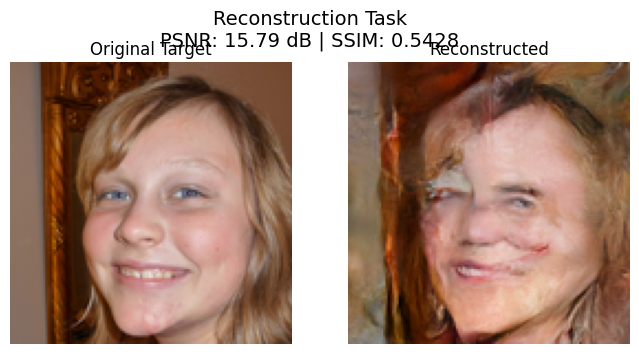

In [9]:
# ==========================================
# 8. Image Reconstruction Task & Metrics (Part 5)
# ==========================================
def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(1.0 / math.sqrt(mse.item()))

def calculate_ssim(img1, img2):
    # Convert [C, H, W] tensors to [H, W, C] numpy arrays in [0, 1] range
    i1 = denormalize(img1).permute(1, 2, 0).cpu().numpy()
    i2 = denormalize(img2).permute(1, 2, 0).cpu().numpy()
    # Provide explicitly the channel axis for color images
    return ssim(i1, i2, data_range=1.0, channel_axis=-1)

# To reconstruct, we add noise up to t=150 (halfway) and then denoise.
# Unconditional DDPMs from pure noise generate random faces, so partial noising 
# is used for the Reconstruction Task.
target = dataset[1].unsqueeze(0).to(cfg.DEVICE)
reconstruct_t = cfg.TIMESTEPS // 2

# Add noise to target
t_tensor = torch.tensor([reconstruct_t]).to(cfg.DEVICE)
noisy_target = q_sample(target, t_tensor)

# Reverse process to reconstruct
reconstructed = p_sample_loop(model, target.shape, start_t=reconstruct_t, start_img=noisy_target)

# Evaluate
psnr_score = calculate_psnr(target[0], reconstructed[0])
ssim_score = calculate_ssim(target[0], reconstructed[0])

# Visualize Target vs Generated
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle(f"Reconstruction Task\nPSNR: {psnr_score:.2f} dB | SSIM: {ssim_score:.4f}", fontsize=14)

axes[0].imshow(denormalize(target[0]).permute(1, 2, 0).cpu().numpy())
axes[0].set_title("Original Target")
axes[0].axis("off")

axes[1].imshow(denormalize(reconstructed[0]).permute(1, 2, 0).cpu().numpy())
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.show()